# Imports and GPU setup

We need to install the latests versions of keras-hub and tensorflow to have access to tools like the Backbone keras models.

In [ ]:
# Run this in a fresh runtime, before importing tensorflow / keras / keras_hub
!pip uninstall -y tensorflow tensorflow-text keras keras-hub tf-keras
!pip install -U tensorflow tensorflow-text keras keras-hub
!pip install -q umap-learn

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: keras-hub 0.26.0
Uninstalling keras-hub-0.26.0:
  Successfully uninstalled keras-hub-0.26.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 151.8 MB/s eta 0:00:0

In [ ]:
# Imports needed to run this notebook
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import json
from pathlib import Path
from PIL import Image

# Dataset download imports
from google.colab import drive
import kagglehub

# ML imports
import tensorflow as tf
import keras
import keras_hub
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

import umap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

Check and setup GPU if present:

In [ ]:
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print("Strategy:", type(strategy).__name__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy


Configuration fields for the model and trainning

In [ ]:
# Model & training
IMG_SIZE = 224
MAX_LEN = 32
EMBED_DIM = 256
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4

# Performance
AUTOTUNE = tf.data.AUTOTUNE

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Downloading and preparing the dataset

Lets load the input dataset chosen, a **lung and colon cancer** *histopathological image* dataset: https://arxiv.org/pdf/1912.12142v1

This dataset contains 25,000 histopathological images, patches of Whole Slide Images (WSI) for lung and colon tissues. All images are 768 x 768 pixels in size and are in jpeg file format.

Images are categorized in 5 classes:
- Lung bening tisues
- Lung adenocarcinoma
- Lung squamous cell carcinoma
- Colon bening tissue
- Colon adenocarcinoma



## Download the dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-and-colon-cancer-histopathological-images


After exploring the downloaded dataset, lets load it:

In [ ]:
base_dir = path + "/lung_colon_image_set"

CLASS_INFO = [
    {
        "id": "lung_n",
        "subdir": "lung_image_sets/lung_n",
        "prompt": "A histopathology image of lung benign tissue",
    },
    {
        "id": "lung_aca",
        "subdir": "lung_image_sets/lung_aca",
        "prompt": "A histopathology image of lung adenocarcinoma",
    },
    {
        "id": "lung_scc",
        "subdir": "lung_image_sets/lung_scc",
        "prompt": "A histopathology image of lung squamous cell carcinoma",
    },
    {
        "id": "colon_n",
        "subdir": "colon_image_sets/colon_n",
        "prompt": "A histopathology image of colon benign tissue",
    },
    {
        "id": "colon_aca",
        "subdir": "colon_image_sets/colon_aca",
        "prompt": "A histopathology image of colon adenocarcinoma",
    },
]

In [ ]:
class_names = [c["id"] for c in CLASS_INFO]
class_prompts = [c["prompt"] for c in CLASS_INFO]
class_dirs = [os.path.join(base_dir, c["subdir"]) for c in CLASS_INFO]

name_to_prompt = {c["id"]: c["prompt"] for c in CLASS_INFO}
prompt_to_name = {c["prompt"]: c["id"] for c in CLASS_INFO}

prompt_to_id = {p: i for i, p in enumerate(class_prompts)}
id_to_prompt = {i: p for p, i in prompt_to_id.items()}
id_to_name = {i: prompt_to_name[p] for i, p in id_to_prompt.items()}

**Assumptions taken:**

- All images of the dataset have the same shape
- All images loaded are JPEG format
- Each image on each directory contains sufficient information for an AI model to deduce the class of the image

In [ ]:
sample_img = os.listdir(class_dirs[0])[0]
sample_path = os.path.join(class_dirs[0], sample_img)

with Image.open(sample_path) as img:
    sample = np.array(img)

H, W, C = sample.shape
H,W,C

(768, 768, 3)

Lets now check the images loaded to learn the dataset's structure

In [ ]:
images_per_class = [len(os.listdir(d)) for d in class_dirs]
total_images = sum(images_per_class)

print("Images per class:", images_per_class)
print("Total images:", total_images)

Images per class: [5000, 5000, 5000, 5000, 5000]
Total images: 25000


Load the labels

In [ ]:
records = []
labels = []

for class_info in CLASS_INFO:
    dir_path = os.path.join(base_dir, class_info["subdir"])
    for fname in sorted(os.listdir(dir_path)):
        if fname.lower().endswith((".jpg", ".jpeg")):
            records.append(os.path.join(dir_path, fname))
            labels.append(class_info["prompt"])

Load the images

## Visualize the dataset

In [ ]:
idx = np.random.randint(len(records))
print(records[idx])
print(labels[idx])

/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/colon_aca/colonca4288.jpeg
A histopathology image of colon adenocarcinoma


In [ ]:
# Helper function to visualize the images and labels of the dataset
def show_sample(records, labels, index):
    if index < 0 or index >= len(records):
        raise IndexError(f"Index {index} out of range (0 - {len(records)-1})")

    img_path, label = records[index], labels[index]
    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"Description: {label}", fontsize=12)
    plt.axis("off")
    plt.show()

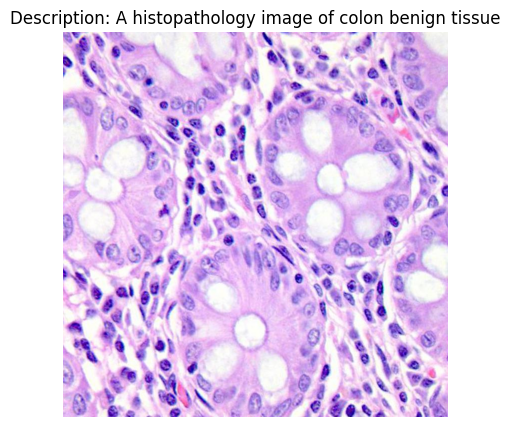

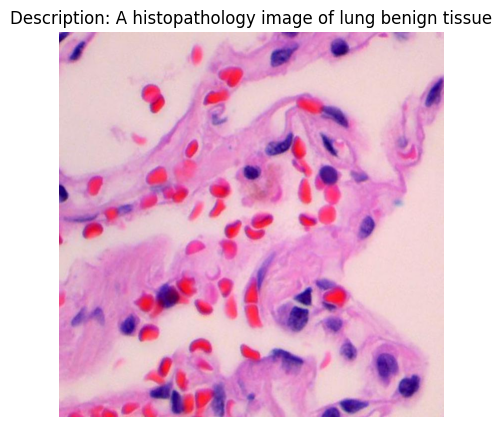

In [ ]:
idx1, idx2 = np.random.randint(len(records)), np.random.randint(len(records))
show_sample(records, labels, idx1)
show_sample(records, labels, idx2)

# Model

We will be using the CLIP model (Contrastive Language-Image Pre-training), https://openai.com/index/clip/. This model is able to learn from text-images pairs, creating a shared embedding space for both. It is considered a foundational model and used on tasks such as zero-shot classification or image retrieval.

CLIP requires 2 backbone models, a image and a text model.

**Image backbone**: We will be using [**ResNet50**](https://arxiv.org/abs/1512.03385) as the image model, a well-known CNN architecture that leverages skip connections to allow information to flow more easily across layers. This design helps mitigate the vanishing gradient problem in deep networks, enabling the training of much deeper models. ResNet achieved very strong results in the ImageNet challenge and has since become a standard backbone for many computer vision tasks. Therefore, we will use the pretrained version available in Keras Hub, initialized with ImageNet weights (`resnet_50_imagenet preset`).

**Text backbone**: We will use a pretrained [**BERT**](https://arxiv.org/abs/1810.04805) (Bidirectional Encoder Representations from Transformers) model for the text backbone. BERT is a widely used language model introduced by Google AI in 2018, designed to process text bidirectionally, meaning it can learn contextual relationships between words by considering both left and right context simultaneously. It relies on the transformer encoder architecture to generate rich semantic representations of text. In the context of CLIP, we will leverage BERT to encode the textual descriptions into dense feature embeddings that can be aligned with the image embeddings produced by the ResNet50 backbone. This will allow the model to learn a shared embedding space where semantically related images and text are close to each other in the embedding space. We will use the pretrainned version of the BERT base model, available in keras_hub (`bert_base_en_uncased` preset). We will also define the BERT preprocesor to tokenize the description strings for BERT to generate embeddings.

## Define the model

Define the text and image backbone models. Freeze them initially.

In [ ]:
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
text_backbone = keras_hub.models.Backbone.from_preset("bert_base_en_uncased")
text_preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=MAX_LEN,
)

image_backbone.trainable = True
text_backbone.trainable = False

image_backbone.summary()
text_backbone.summary()

Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │      4,096 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_re… │ (None, None,      │          0 │ stack0_block0_2_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_0_co… │ (None, None,      │     16,384 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_3_co… │ (None, None,      │     16,384 │ stack0_block0_2_… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_0_bn  │ (None, None,      │      1,024 │ stack0_block0_0_… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_3_bn  │ (None, None,      │      1,024 │ stack0_block0_3_

 Total params: 23,561,152 (89.88 MB)

 Trainable params: 23,508,032 (89.68 MB)

 Non-trainable params: 53,120 (207.50 KB)

Model: "bert_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, None, 768) │ 23,440,896 │ token_ids[0][0]   │
│ (ReversibleEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 768) │    393,216 │ token_embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_embedding   │ (None, None, 768) │      1,536 │ segment_ids[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_add      │ (None, None, 768) │          0 │ token_embedding[… │
│ (Add)               │                   │            │ position_embeddi… │
│                     │                   │            │ segment_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_layer_n… │ (None, None, 768) │      1,536 │ embeddings_add[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_dropout  │ (None, None, 768) │          0 │ embeddings_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_0 │ (None, None, 768) │  7,087,872 │ embeddings_dropo… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_2 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_3 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_4 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_5 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_6 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 109,482,240 (417.64 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 109,482,240 (417.64 MB)

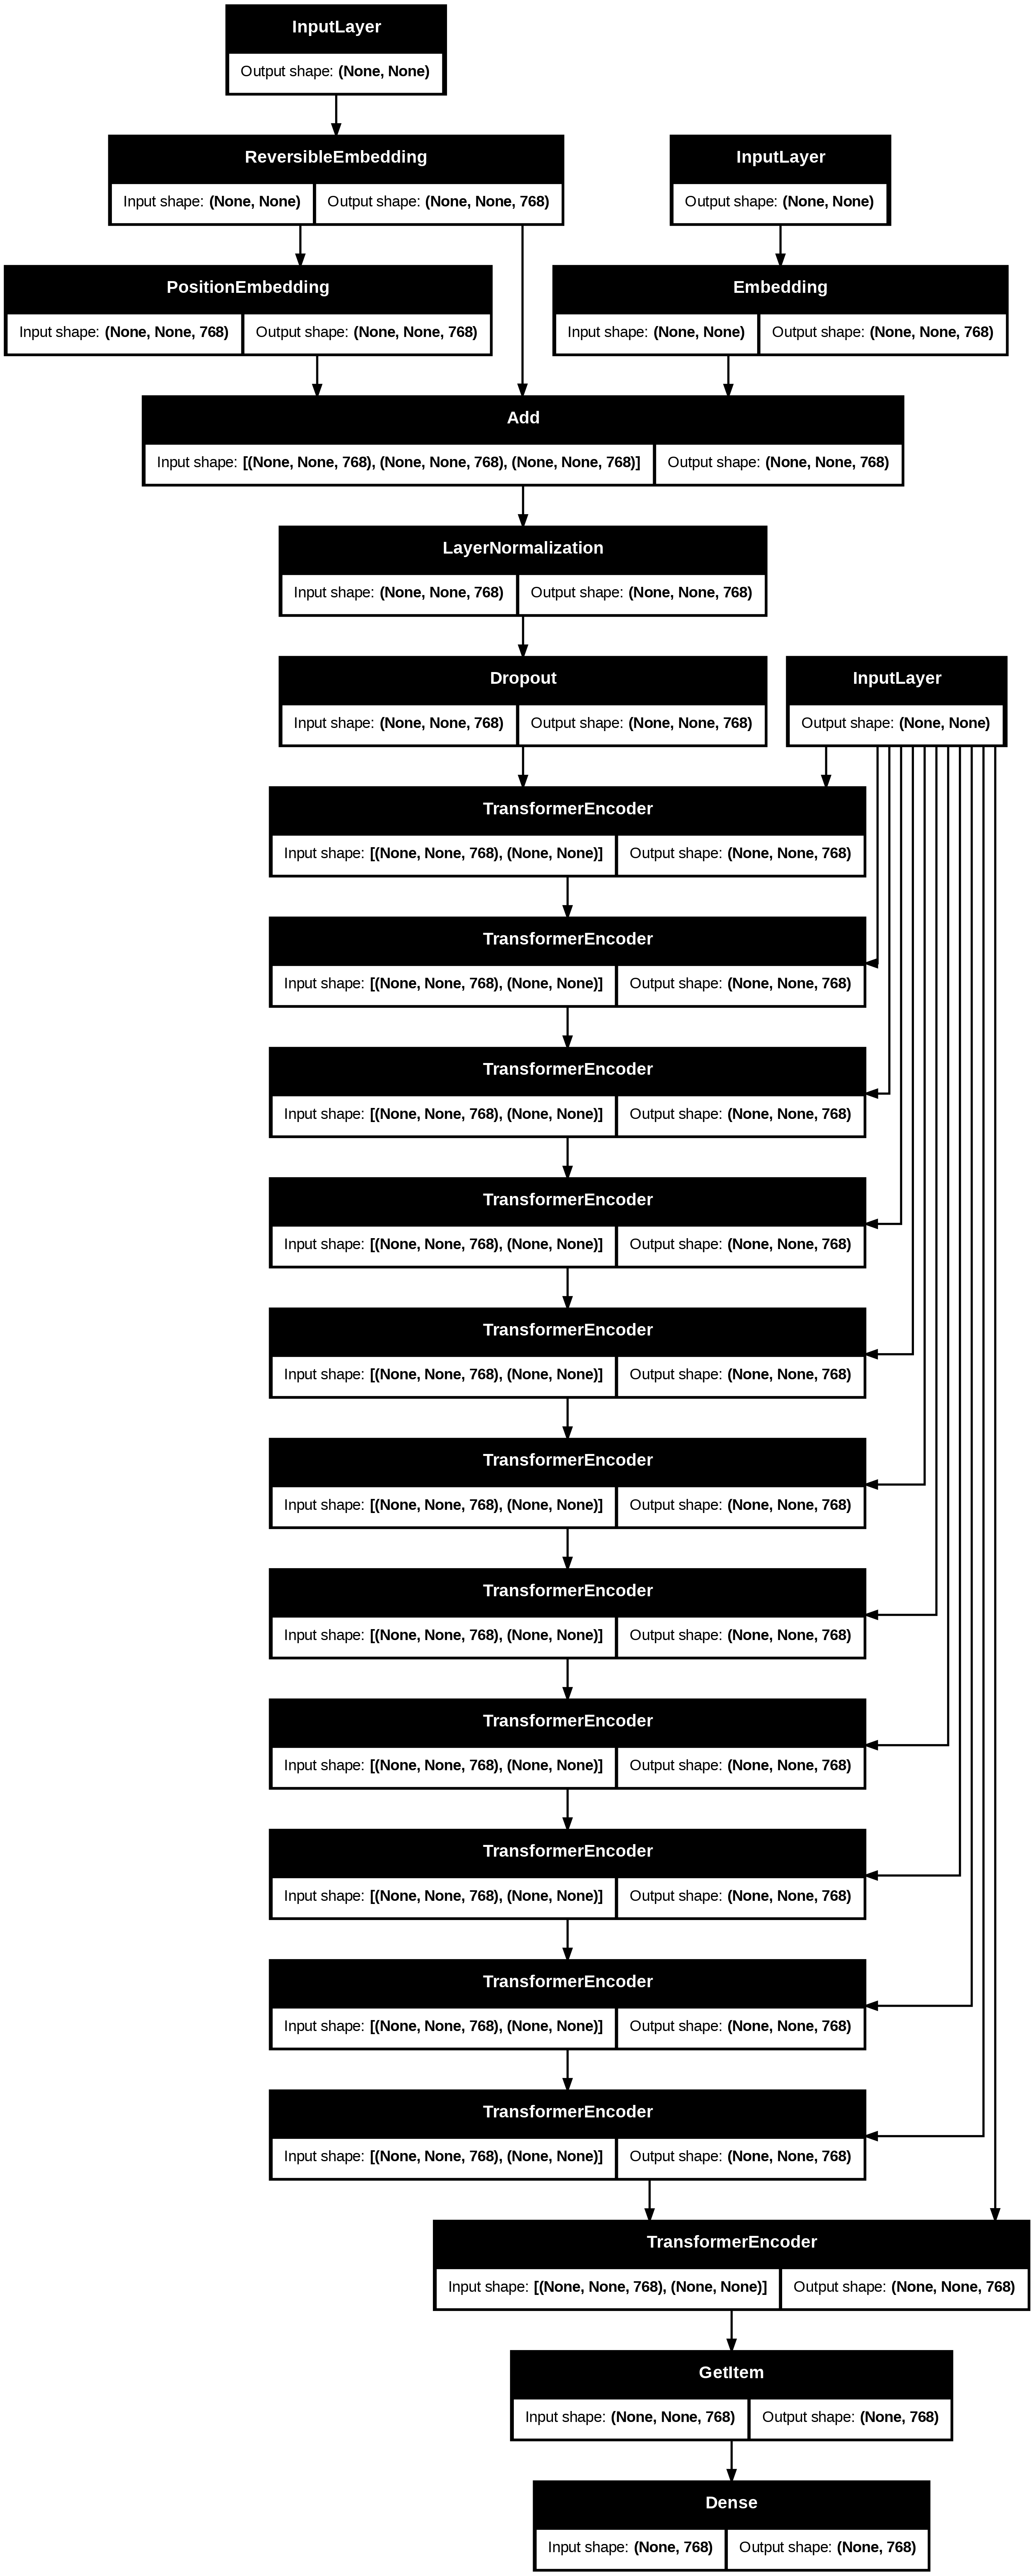

In [ ]:
# Visualize the model
plot_model(image_backbone, show_shapes=True, expand_nested=True)
plot_model(text_backbone, show_shapes=True, expand_nested=True)

Define a custom model (Keras' model doesn't support ResNet image encoder).

In [ ]:
class CLIPModel(keras.Model):
    def __init__(self, img_backbone, text_backbone, embed_dim=256, init_temp=0.1):
        super().__init__()
        # Store image and text backbone models
        self.img_backbone = img_backbone
        self.text_backbone = text_backbone

        # Projection layers to ensure embeddings dimensions of image and text models match
        self.img_projection = keras.layers.Dense(embed_dim, use_bias=False)
        self.text_projection = keras.layers.Dense(embed_dim, use_bias=False)

        # Configure temperature to try control distance between embedding clusters
        self.logit_scale = self.add_weight(
            name="logit_scale",
            shape=(),
            initializer=tf.keras.initializers.Constant(
                tf.math.log(1.0 / init_temp).numpy()
            ),
            trainable=True,
            dtype=tf.float32,
        )

        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, images, training=False):
        backbone_training = training and self.img_backbone.trainable
        x = self.img_backbone(images, training=backbone_training)

        # Global average pooling
        if len(x.shape) == 4:
            x = tf.reduce_mean(x, axis=[1, 2])
        else:
            raise ValueError(f"Unexpected image backbone output shape: {x}")

        # Projection of image features into CLIP embeddings dimensions
        x = self.img_projection(x)
        # Normalization of the embeddings
        x = tf.math.l2_normalize(x, axis=-1)

        return x

    def encode_text(self, token_dict, training=False):
        backbone_training = training and self.text_backbone.trainable
        out = self.text_backbone(token_dict, training=backbone_training)

        if isinstance(out, dict):
            if "pooled_output" in out:
                # We expect the output of the BERT model to return this key
                x = out["pooled_output"]
            elif "sequence_output" in out:
                x = out["sequence_output"][:, 0, :]
            else:
                raise ValueError(f"Unexpected BERT output keys: {list(out.keys())}")
        else:
            if len(out.shape) == 3:
                x = out[:, 0, :]
            else:
                x = out

        # Projection of text features into CLIP embeddings dimensions
        x = self.text_projection(x)
        # Normalization of the embeddings
        x = tf.math.l2_normalize(x, axis=-1)

        return x

    def compute_clip_loss(self, img_emb, txt_emb):
        # 1 - Cast to float32 to avoid numeric instability (Do I need this?)
        img_emb = tf.cast(img_emb, tf.float32)
        txt_emb = tf.cast(txt_emb, tf.float32)

        # Keep trainable temperature within a safe range
        logit_scale = tf.exp(tf.clip_by_value(self.logit_scale, 0.0, tf.math.log(100.0)))

        # Matrix multiplication to get similarity matrix
        logits = tf.matmul(img_emb, txt_emb, transpose_b=True) * logit_scale
        logits = tf.clip_by_value(logits, -100.0, 100.0)

        labels = tf.range(tf.shape(logits)[0])

        # Compute two losses
        # Image -> text loss
        loss_i2t = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=logits
        )
        # Text -> image loss
        loss_t2i = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=tf.transpose(logits)
        )

        # Average of both loss values
        loss = 0.5 * (loss_i2t + loss_t2i)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        images, token_dict = data

        with tf.GradientTape() as tape:
            img_emb = self.encode_image(images, training=True)
            txt_emb = self.encode_text(token_dict, training=True)
            loss = self.compute_clip_loss(img_emb, txt_emb)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        return {
            "loss": self.loss_tracker.result(),
            "temperature": tf.exp(-self.logit_scale),
        }

    def test_step(self, data):
        images, token_dict = data
        img_emb = self.encode_image(images, training=False)
        txt_emb = self.encode_text(token_dict, training=False)
        loss = self.compute_clip_loss(img_emb, txt_emb)

        self.loss_tracker.update_state(loss)
        return {
            "loss": self.loss_tracker.result(),
            "temperature": tf.exp(-self.logit_scale),
        }

    def call(self, inputs, training=False):
        images, token_dict = inputs
        img_emb = self.encode_image(images, training=training)
        txt_emb = self.encode_text(token_dict, training=training)
        return {"image_embeddings": img_emb, "text_embeddings": txt_emb}

In [ ]:
model = CLIPModel(image_backbone, text_backbone, embed_dim=EMBED_DIM)

optimizer = keras.optimizers.Adam(
    learning_rate=1e-4,
    global_clipnorm=1.0,
)
model.compile(optimizer=optimizer)

model.summary()

Model: "clip_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ res_net_backbone                │ (None, None, None,     │    23,561,152 │
│ (ResNetBackbone)                │ 2048)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bert_backbone (BertBackbone)    │ ((None, 768), (None,   │   109,482,240 │
│                                 │ None, 768))            │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,043,393 (507.52 MB)

 Trainable params: 23,508,033 (89.68 MB)

 Non-trainable params: 109,535,360 (417.84 MB)

In [ ]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = keras.applications.resnet.preprocess_input(img)
    return img

In [ ]:
def preprocess_example(img_path, text):
    image = load_image(img_path)
    token_dict = text_preprocessor(text)
    return image, token_dict

## Train the model

First we start by dividing the trainning dataset with a train / validate split of 80% - 20%. We build batches of `BATCH_SIZE` of the images & text to input to the model.

In [ ]:
train_records, temp_records, train_labels, temp_labels = train_test_split(
    records,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

val_records, test_records, val_labels, test_labels = train_test_split(
    temp_records,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print(len(train_records), len(val_records), len(test_records))

20000 2500 2500


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((train_records, train_labels))
train_ds = train_ds.shuffle(len(train_records), seed=SEED)
train_ds = train_ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_records, val_labels))
val_ds = val_ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(AUTOTUNE)

Lets explore the batches of the trainning dataset we built. The expectation is to have per bacth:
- `BATCH_SIZE` images of `IMG_SIZE`x`IMG_SIZE`x3 size
- `BATCH_SIZE` tokens of `MAX_LEN` size

In [ ]:
batch = next(iter(train_ds))
images, token_dict = batch

print("Images:", images.shape, images.dtype)
print("Token keys:", token_dict.keys())
for k, v in token_dict.items():
    print(k, v.shape, v.dtype)

Images: (8, 224, 224, 3) <dtype: 'float32'>
Token keys: dict_keys(['token_ids', 'padding_mask', 'segment_ids'])
token_ids (8, 32) <dtype: 'int32'>
padding_mask (8, 32) <dtype: 'bool'>
segment_ids (8, 32) <dtype: 'int32'>


In [ ]:
_ = model((images[:1], {k: v[:1] for k, v in token_dict.items()}), training=False)
print("Model built:", model.built)

Model built: True


In [ ]:
# Quick test to see if the model correctly processes the images and texts into same size:
img_emb = model.encode_image(images[:2], training=False)
txt_emb = model.encode_text({k: v[:2] for k, v in token_dict.items()}, training=False)

print("Image embeddings:", img_emb.shape)
print("Text embeddings:", txt_emb.shape)

Image embeddings: (2, 256)
Text embeddings: (2, 256)


In [ ]:
# Quick test to see if the model can correctly take a trainning step with the input bactches of the dataset:

out = model.train_step(batch)
print("Loss - ", out["loss"])
print("Temperature - ", out["temperature"])

Loss -  tf.Tensor(2.0903897, shape=(), dtype=float32)
Temperature -  tf.Tensor(0.10000999, shape=(), dtype=float32)


CLIP model trainning:

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
    ),
    keras.callbacks.ModelCheckpoint(
        "checkpoints/clip_resnet50_best.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1,
    ),
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
1735/2500 ━━━━━━━━━━━━━━━━━━━━ 1:37 128ms/step - loss: 1.3129 - temperature: 0.0970

KeyboardInterrupt: 

Save the model's execution for future usage.

In [ ]:
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/clip_histopathology_v4"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save model weights
weights_path = os.path.join(SAVE_DIR, "clip_resnet50_v4.weights.h5")
model.save_weights(weights_path)

# 2. Save split
split = {
    "train_records": train_records.tolist() if isinstance(train_records, np.ndarray) else list(train_records),
    "train_labels": train_labels.tolist() if isinstance(train_labels, np.ndarray) else list(train_labels),
    "val_records": val_records.tolist() if isinstance(val_records, np.ndarray) else list(val_records),
    "val_labels": val_labels.tolist() if isinstance(val_labels, np.ndarray) else list(val_labels),
    "test_records": test_records.tolist() if isinstance(test_records, np.ndarray) else list(test_records),
    "test_labels": test_labels.tolist() if isinstance(test_labels, np.ndarray) else list(test_labels),
}

with open(os.path.join(SAVE_DIR, "split.json"), "w") as f:
    json.dump(split, f)

# 3. Save training history if available
if "history" in globals():
    with open(os.path.join(SAVE_DIR, "history.json"), "w") as f:
        json.dump(history.history, f)

print("Saved snapshot to:", SAVE_DIR)
print(" - weights: clip_resnet50_v4.weights.h5")
print(" - split: split.json")
if "history" in globals():
    print(" - history: history.json")

## Load previous trainning

In [ ]:
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/clip_histopathology_v4"

# 1. Load split
with open(os.path.join(SAVE_DIR, "split.json"), "r") as f:
    split = json.load(f)

train_records = np.array(split["train_records"])
train_labels = np.array(split["train_labels"])
val_records = np.array(split["val_records"])
val_labels = np.array(split["val_labels"])
test_records = np.array(split["test_records"])
test_labels = np.array(split["test_labels"])

# 2. Rebuild tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_records, train_labels))
train_ds = train_ds.shuffle(len(train_records), seed=SEED)
train_ds = train_ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_records, val_labels))
val_ds = val_ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(AUTOTUNE)

# If you have a separate test preprocessing function that returns (image, class_id),
# rebuild test_ds with that later. Otherwise keep raw split loaded and rebuild as needed.

# 3. Recreate model
model = CLIPModel(image_backbone, text_backbone, embed_dim=EMBED_DIM)
model.compile(optimizer=optimizer)

# 4. Build model once before loading weights
batch = next(iter(train_ds))
images, token_dict = batch
_ = model((images[:1], {k: v[:1] for k, v in token_dict.items()}), training=False)

# 5. Load weights
weights_path = os.path.join(SAVE_DIR, "clip_resnet50_v4.weights.h5")
model.load_weights(weights_path)

# 6. Load training history if available
history_path = os.path.join(SAVE_DIR, "history.json")
if os.path.exists(history_path):
    with open(history_path, "r") as f:
        history = json.load(f)
else:
    history = None

print("Loaded snapshot from:", SAVE_DIR)
print("Train/Val/Test sizes:", len(train_records), len(val_records), len(test_records))
print("Weights loaded successfully.")
if history is not None:
    print("History loaded successfully.")

# Results

## Visualization of the results

### Train / Validation loss

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training VS Validation loss")
plt.show()

### Zero shot classification

Visualize a few predictions made by the model (zero-shot classification)

In [ ]:
class_token_dict = text_preprocessor(tf.constant(class_prompts))
class_text_emb = model.encode_text(class_token_dict, training=False)

In [ ]:
# Quick test with a single, random image
idx = np.random.randint(len(val_records))

img_path = val_records[idx]
true_label = val_labels[idx]

image = load_image(img_path) # (IMG_SIZE, IMG_SIZE, 3)
image_batch = tf.expand_dims(image, axis=0) # (1, IMG_SIZE, IMG_SIZE, 3)

img_emb = model.encode_image(image_batch, training=False) # (1, EMBED_DIM)
# Dot product to compute cosune similarity to classes
scores = tf.matmul(img_emb, class_text_emb, transpose_b=True).numpy()[0]

# Takes highest similiarity score as prediction
pred_idx = np.argmax(scores)
pred_label = class_names[pred_idx]

# Print prediction values
print("Image path:", img_path)
print("True label:", true_label)
print("Predicted label:", name_to_prompt[pred_label])
print()
print("Scores:")
for cname, score in zip(class_names, scores):
    print(f"{cname:10s} -> {score:.4f}")
print()


# Plot image
plt.figure(figsize=(5,5))

img_show = image.numpy()
img_show = img_show[..., ::-1]   # BGR -> RGB
img_show = img_show - img_show.min()
img_show = img_show / (img_show.max() + 1e-8)

plt.imshow(img_show)
plt.title(f"True: {true_label}\nPred: {name_to_prompt[pred_label]}")
plt.axis("off")
plt.show()

Accuracy and Macro F1 metrics

In [ ]:
# Create test evaluation dataset to visualize model results

prompt_to_id = {p: i for i, p in enumerate(class_prompts)}
id_to_prompt = {i: p for p, i in prompt_to_id.items()}

keys = tf.constant(class_prompts)
values = tf.constant(np.arange(len(class_prompts)), dtype=tf.int32)

table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values),
    default_value=-1
)

def preprocess_eval_example(img_path, label):
    image = load_image(img_path)
    class_id = table.lookup(label)
    return image, class_id

test_ds = tf.data.Dataset.from_tensor_slices((test_records, test_labels))
test_ds = test_ds.map(preprocess_eval_example, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
all_preds = []
all_true = []
all_img_emb = []

for images, true_ids in test_ds:
    img_emb = model.encode_image(images, training=False)
    scores = tf.matmul(img_emb, class_text_emb, transpose_b=True)
    pred_ids = tf.argmax(scores, axis=1, output_type=tf.int32)

    all_preds.extend(pred_ids.numpy().tolist())
    all_true.extend(true_ids.numpy().tolist())
    all_img_emb.extend(images.numpy())


all_preds = np.array(all_preds, dtype=np.int32)
all_true = np.array(all_true, dtype=np.int32)
all_img_emb = np.array(all_img_emb)

acc = (all_preds == all_true).mean()
macro_f1 = f1_score(all_true, all_preds, average="macro")
print("Test accuracy:", acc)
print("Test macro F1:", macro_f1)

Evaluation metrics

In [ ]:
# Create test retrieval dataset to visualize model results

def preprocess_retrieval_example(img_path, label):
    image = load_image(img_path)
    return image, label

test_retrieval_ds = tf.data.Dataset.from_tensor_slices((test_records, test_labels))
test_retrieval_ds = test_retrieval_ds.map(
    preprocess_retrieval_example,
    num_parallel_calls=AUTOTUNE
)
test_retrieval_ds = test_retrieval_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
all_img_emb = []
all_txt_emb = []
all_label_ids = []

for images, labels in test_retrieval_ds:
    token_dict = text_preprocessor(labels)

    img_emb = model.encode_image(images, training=False)
    txt_emb = model.encode_text(token_dict, training=False)

    all_img_emb.append(img_emb.numpy())
    all_txt_emb.append(txt_emb.numpy())

    # convert prompt strings back to class ids
    batch_label_ids = [prompt_to_id[label.decode("utf-8") if isinstance(label, bytes) else label]
                       for label in labels.numpy()]
    all_label_ids.extend(batch_label_ids)

all_img_emb = np.concatenate(all_img_emb, axis=0)
all_txt_emb = np.concatenate(all_txt_emb, axis=0)
all_label_ids = np.array(all_label_ids, dtype=np.int32)

In [ ]:
ranks_i2t = []
ranks_t2i = []

# Normalize embeddings
img_emb = all_img_emb / np.linalg.norm(all_img_emb, axis=1, keepdims=True)
txt_emb = all_txt_emb / np.linalg.norm(all_txt_emb, axis=1, keepdims=True)

# Similarity matrix
S = img_emb @ txt_emb.T

# Image -> Text
for i in range(S.shape[0]):
    order = np.argsort(-S[i])  # texts ranked for image i
    correct_texts = np.where(all_label_ids == all_label_ids[i])[0]
    rank = min(np.where(order == j)[0][0] for j in correct_texts)
    ranks_i2t.append(rank)

# Text -> Image
for j in range(S.shape[1]):
    order = np.argsort(-S[:, j])  # images ranked for text j
    correct_images = np.where(all_label_ids == all_label_ids[j])[0]
    rank = min(np.where(order == i)[0][0] for i in correct_images)
    ranks_t2i.append(rank)

def recall_at_k(ranks, k):
    return np.mean(np.array(ranks) < k)

print("I→T R@1:", recall_at_k(ranks_i2t, 1))
print("I→T R@5:", recall_at_k(ranks_i2t, 5))

print("T→I R@1:", recall_at_k(ranks_t2i, 1))
print("T→I R@5:", recall_at_k(ranks_t2i, 5))

print("Mean rank I→T:", np.mean(ranks_i2t))
print("Median rank I→T:", np.median(ranks_i2t))

In [ ]:
n_show = 8
idxs = np.random.choice(len(all_true), size=n_show, replace=False)

plt.figure(figsize=(16, 8))
for i, idx in enumerate(idxs):
    plt.subplot(2, 4, i + 1)

    img = all_img_emb[idx]
    img = img[..., ::-1]
    img = img - img.min()
    img = img / (img.max() + 1e-8)

    true_label = id_to_prompt[int(all_true[idx])]
    pred_label = id_to_prompt[int(all_preds[idx])]

    plt.imshow(img)
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Confusion matrix

In [ ]:
cm = confusion_matrix(all_true, all_preds, labels=list(range(len(class_prompts))))

fig, ax = plt.subplots(figsize=(7,7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_prompts)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Test Confusion Matrix")
plt.show()

### UMAP visualization

In [ ]:
all_emb = []

for images, _ in test_ds:
    emb = model.encode_image(images, training=False)
    all_emb.append(emb.numpy())

all_emb = np.concatenate(all_emb, axis=0)

print("Embedding shape:", all_emb.shape)

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

emb_2d = reducer.fit_transform(all_emb)

print(emb_2d.shape)

In [ ]:
plt.figure(figsize=(8,6))

for i, prompt in id_to_prompt.items():
    idx = all_true == i
    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        s=8,
        alpha=0.6,
        label=prompt.replace("A histopathology image of ","")
    )

plt.legend()
plt.title("UMAP of Image Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()